# NatureCubePy Visualization Tutorial

This notebook demonstrates every public plotting function in `naturecubepy.viz`, grouped by plot family:

1. **Maps and station activity** — `station_map`, `station_explorer`, `camera_activity_timeline`
2. **Records and species summaries** — `records_per_class`, `plot_top_species`, `plot_top_species_by_sensor`
3. **Species accumulation** — `plot_species_accumulation_mammal_bird_by_sensor`
4. **eDNA and IUCN** — `plot_edna_records`, `plot_edna_unique_taxa_stacked`, `iucn_bar_plot`


In [2]:
import matplotlib.pyplot as plt

from naturecubepy import (
    auth_headers,
    get_audio_observation_data,
    get_camera_trap_data,
    get_edna_observation_data,
    get_key,
    get_project_boundary,
    get_station_info,
)
from naturecubepy.viz import (
    camera_activity_timeline,
    iucn_bar_plot,
    plot_edna_records,
    plot_edna_unique_taxa_stacked,
    plot_species_accumulation_mammal_bird_by_sensor,
    plot_top_species,
    plot_top_species_by_sensor,
    records_per_class,
    station_explorer,
    station_map,
)


In [10]:
# Retrieve API key and set up authentication headers
api_key = get_key("EV1_PROD")
hdr = auth_headers(api_key, "https://naturecube.io/api/")


## Load observation data

Pull stations plus camera, bioacoustic, and eDNA observations used by the plotters below.


In [11]:
stations = get_station_info(hdr, measurement_type="all")
camtrap = get_camera_trap_data(hdr, include_iucn_status=True)
audio = get_audio_observation_data(hdr, include_iucn_status=True)


print(f"Stations: {len(stations)}")
print(f"Camera trap rows: {len(camtrap)}")
print(f"Audio rows: {len(audio)}")

stations.head()


Stations: 5
Camera trap rows: 42
Audio rows: 3
eDNA rows: 0


,geometry,system_type,feature_id,feature_name,system_name,device_id,project_system_record_id,record_count,measurement_type,data_type,project_system_record_start_timestamp,project_system_record_end_timestamp
0,POINT (-3.89937 56.53296),Sensor,2826,,Bolyguard SG2060,00100,3570,13,Camera,image,2017-01-14T00:00:00+00:00,2025-05-14T00:00:00+00:00
1,POINT (-3.86308 56.5134),Sensor,2827,,Bolyguard SG2060,00102,3571,16,Camera,image,2018-01-01T00:00:00+00:00,2025-05-14T00:00:00+00:00
2,POINT (-3.89937 56.53296),Sensor,2826,,Bolyguard SG2060,00100,3570,3,Camera,video,2017-01-14T00:00:00+00:00,2025-05-14T00:00:00+00:00
3,POINT (-3.85161 56.49966),Sensor,4218,TEST1,Bolyguard SG2060,AMIN001,5551,5,Camera,video,2025-09-03T09:28:07.820000+00:00,2025-10-03T09:28:07.820000+00:00
4,POINT (-3.89765 56.50395),Sensor,4962,VIDAUD001,Bolyguard SG2060,01008,6364,5,Camera,video,2022-01-01T00:00:00+00:00,2025-11-27T00:00:00+00:00


## 1. Maps and station activity

Plot sampling locations as a static satellite map, an interactive Folium map, and deployment activity timelines.


### `station_map`

Static PNG-ready map of sampling locations. Marker size scales with record count; color encodes measurement type. Optionally overlay the project boundary.


Retrieving project data...
Received response with status code 200
Project data retrieved successfully
Setting your active project as - EV Zone 1


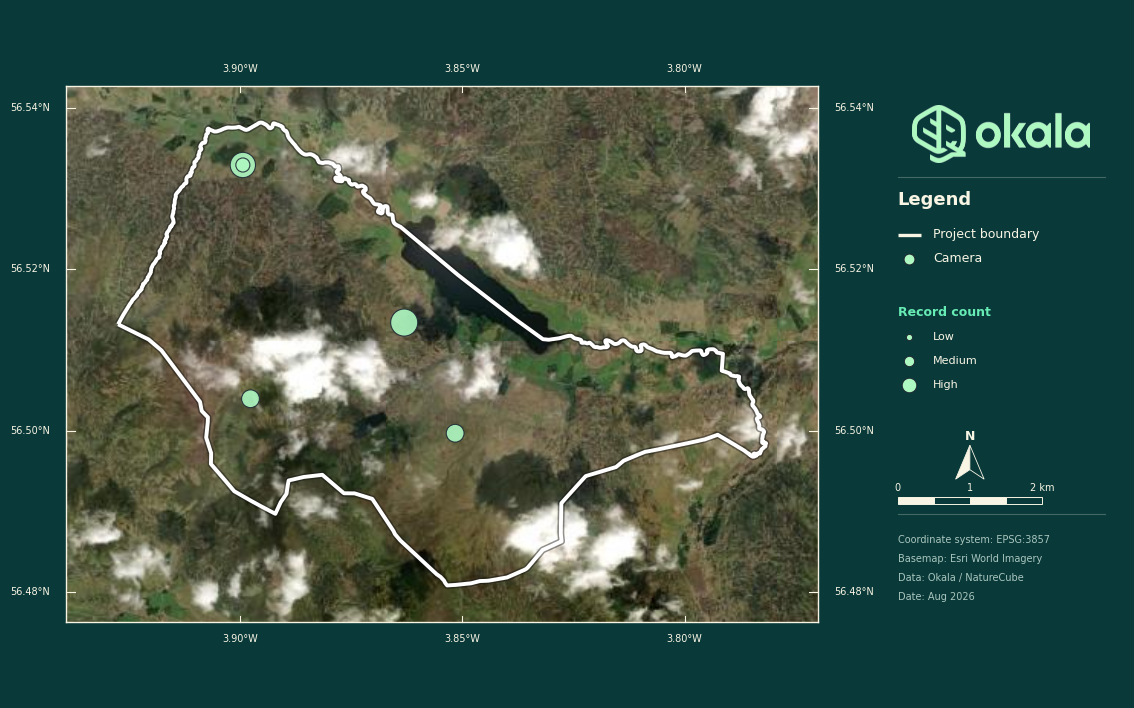

In [14]:
boundary = get_project_boundary(hdr)

fig = station_map(
    stations,
    measurement_type="all",
    project_boundary=boundary,
)


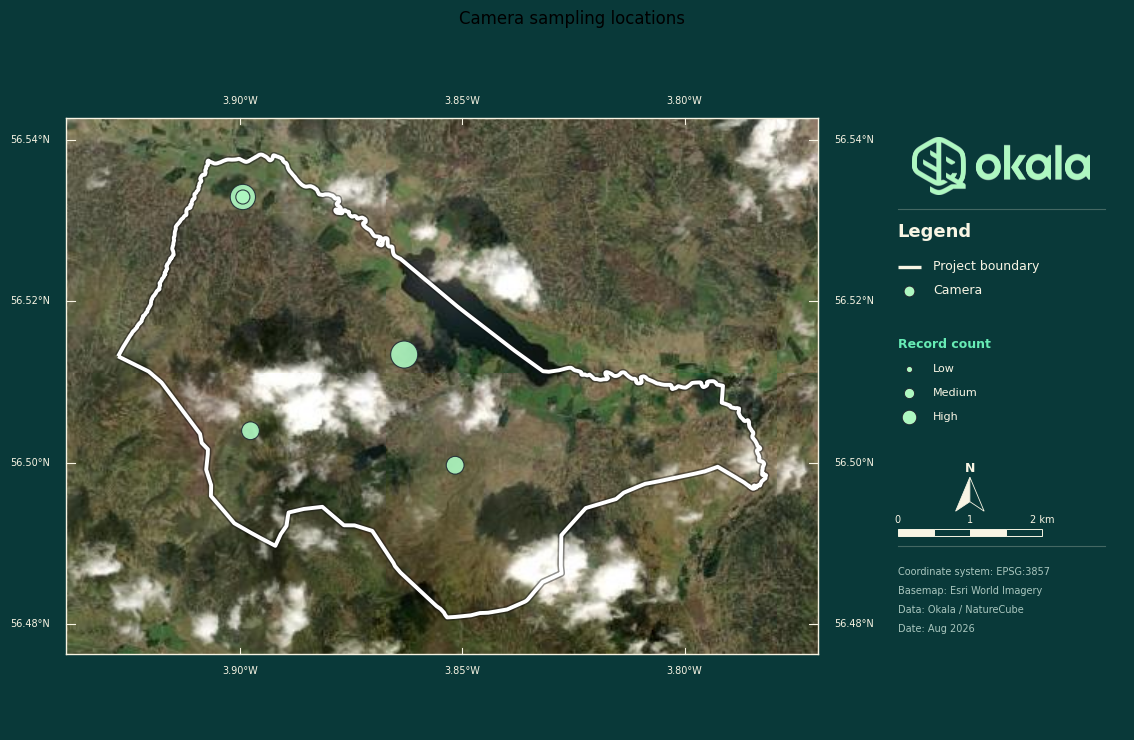

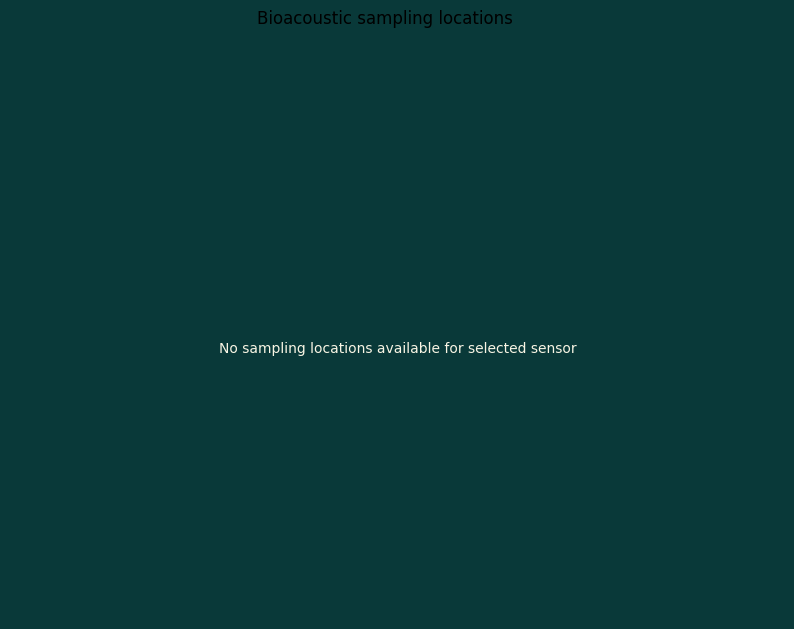

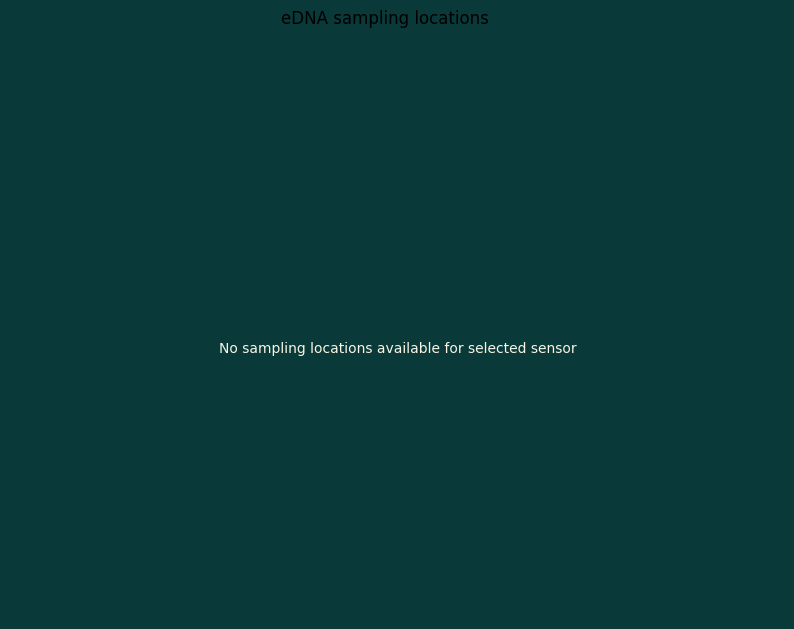

In [15]:
# Sensor-specific static maps
for sensor in ["Camera", "Bioacoustic", "eDNA"]:
    fig = station_map(stations, measurement_type=sensor, project_boundary=boundary)
    fig.suptitle(f"{sensor} sampling locations")
    display(fig)
    plt.close(fig)


### `station_explorer`

Interactive Folium map with popups for device metadata and media counts.


In [ ]:
station_explorer(stations, measurement_type="all")


### `camera_activity_timeline`

Deployment windows for each device. Works for camera or bioacoustic stations when start/end timestamp columns are present.


Camera timeline rows: 3


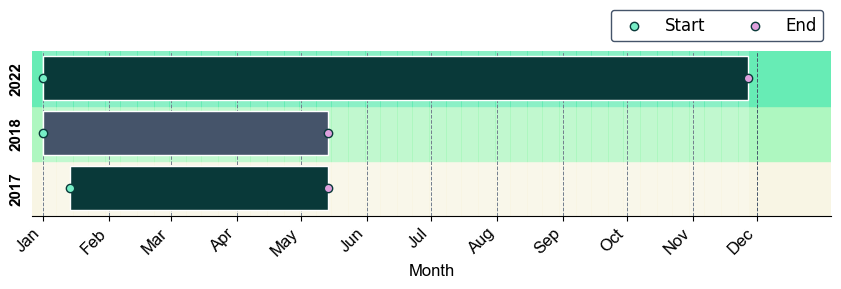

In [17]:
camera_stations = stations[stations["measurement_type"] == "Camera"].copy()
fig, timeline_df = camera_activity_timeline(camera_stations)
print(f"Camera timeline rows: {len(timeline_df)}")



Bioacoustic timeline rows: 0


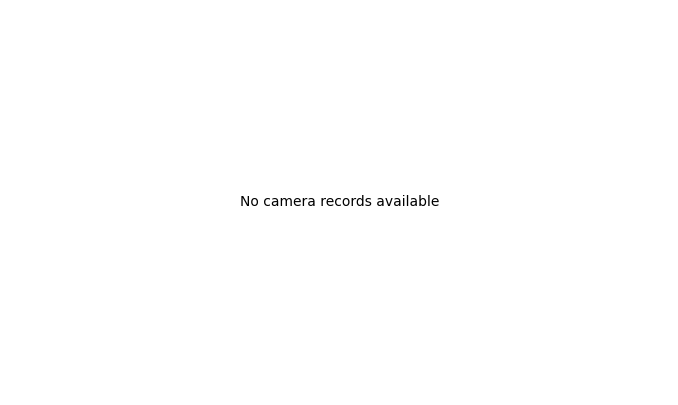

In [18]:
bio_stations = stations[stations["measurement_type"] == "Bioacoustic"].copy()
fig, timeline_df = camera_activity_timeline(bio_stations)
print(f"Bioacoustic timeline rows: {len(timeline_df)}")


## 2. Records and species summaries

Summarise detection volume and the most recorded species by taxonomic class and sensor.


### `records_per_class`

Bar panels for number of records and/or number of species per taxonomic class. Use `panel="both"`, `"records"`, or `"species"`.


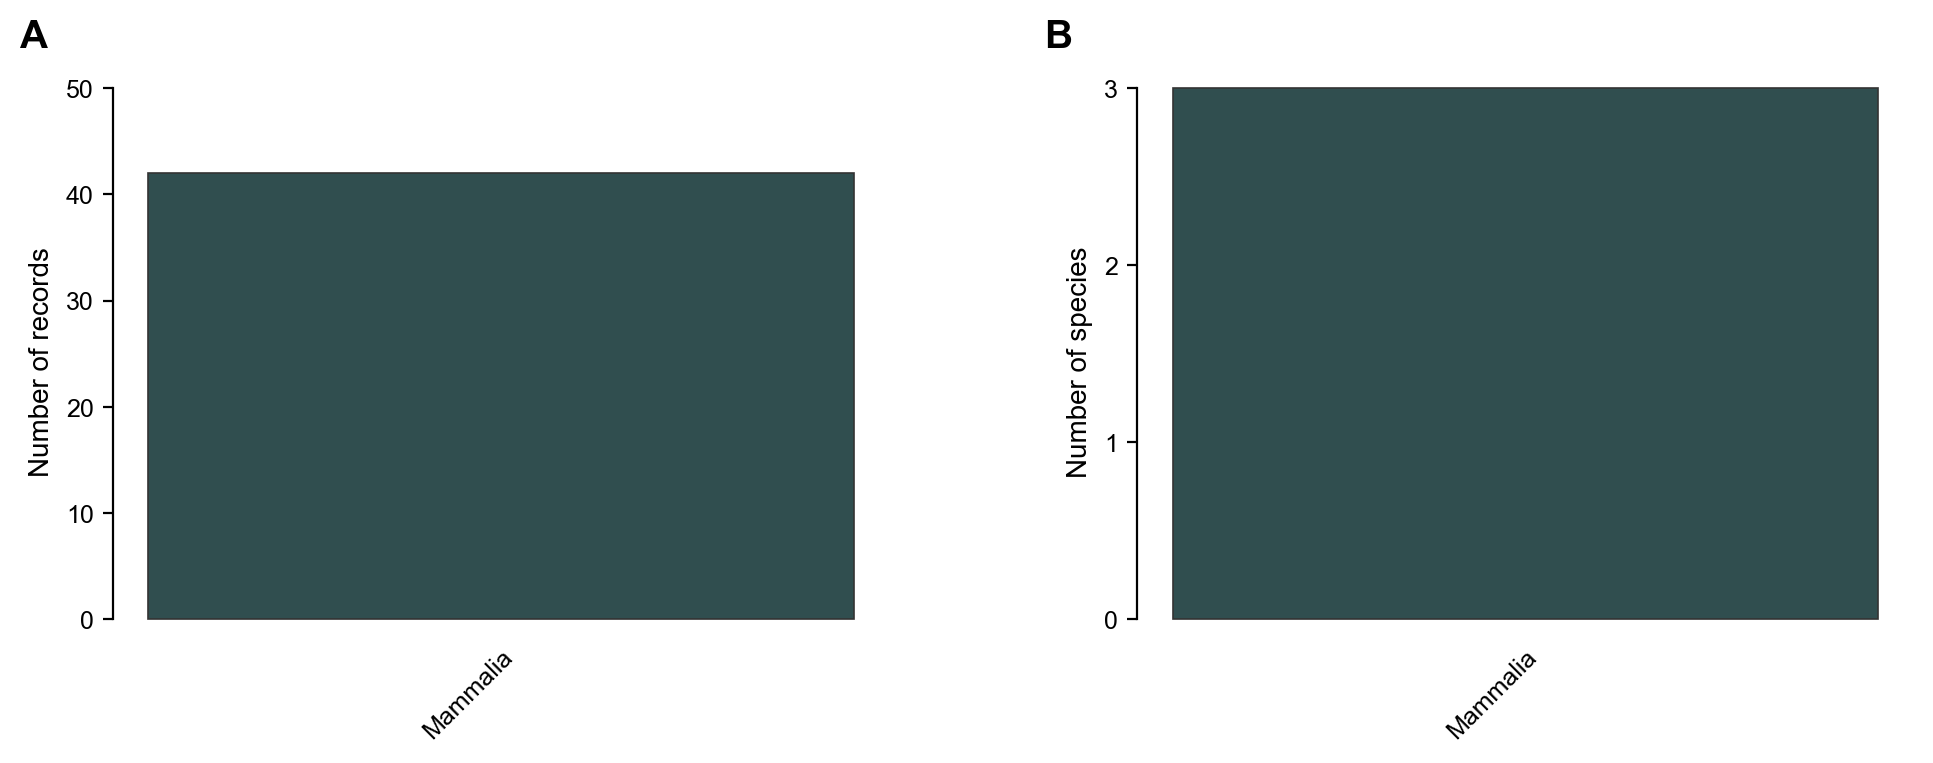

In [19]:
camera_classes = sorted(camtrap["class"].dropna().astype(str).unique())
fig = records_per_class(camtrap, class_levels=camera_classes, panel="both")


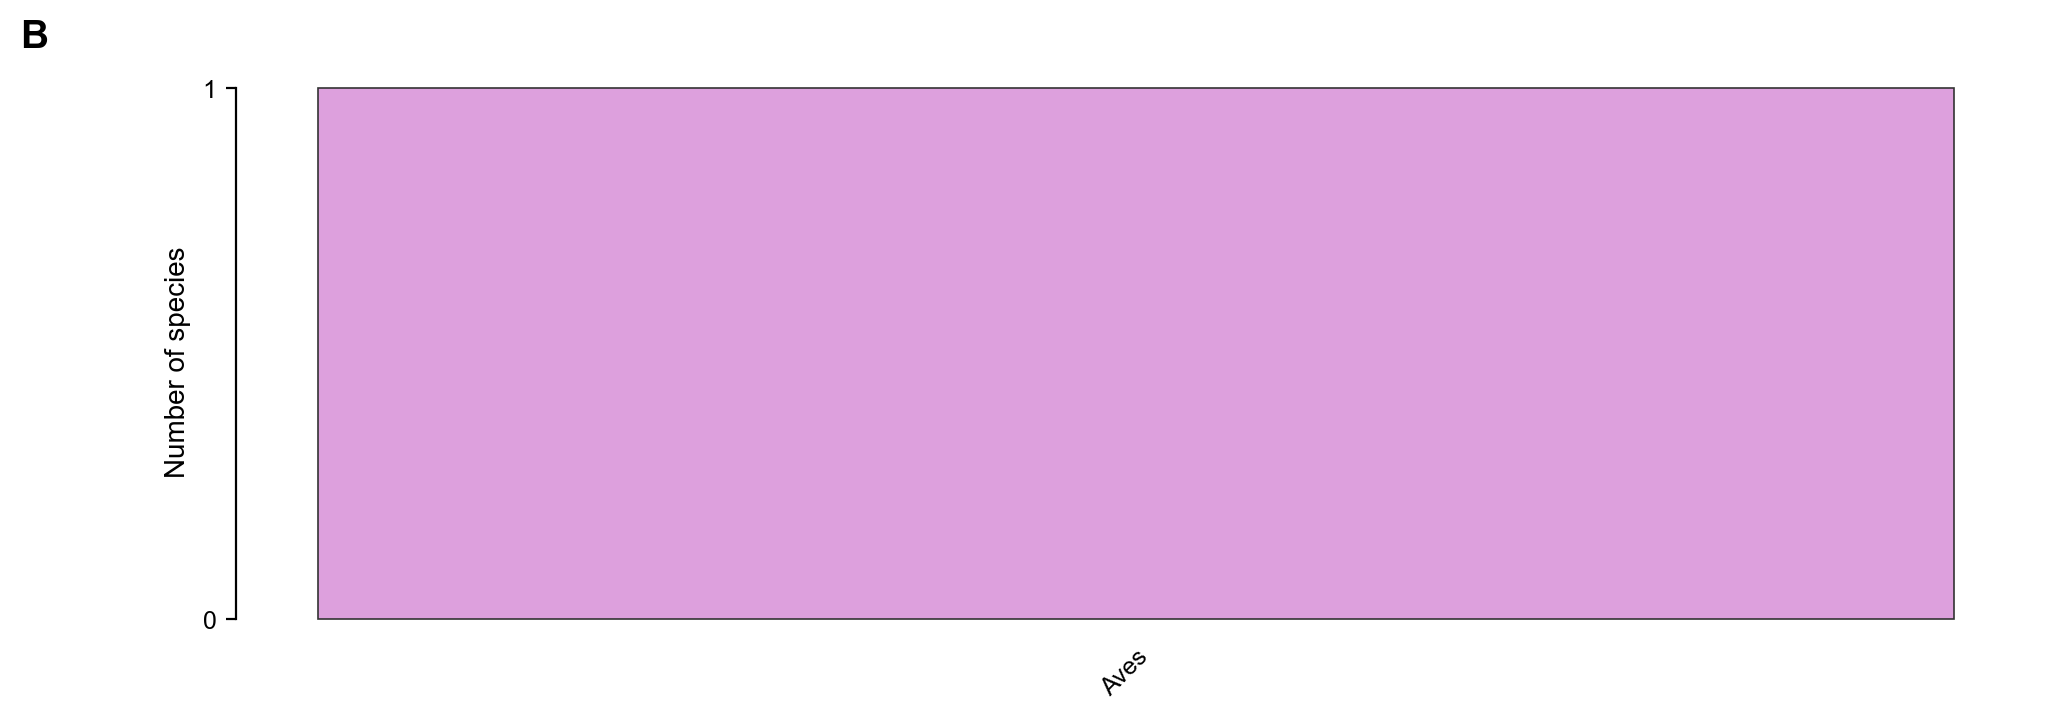

In [20]:
audio_classes = sorted(audio["class"].dropna().astype(str).unique())
fig = records_per_class(audio, class_levels=audio_classes, panel="species")


### `plot_top_species`

Horizontal bar charts of the top *N* species for each class in the supplied color map.


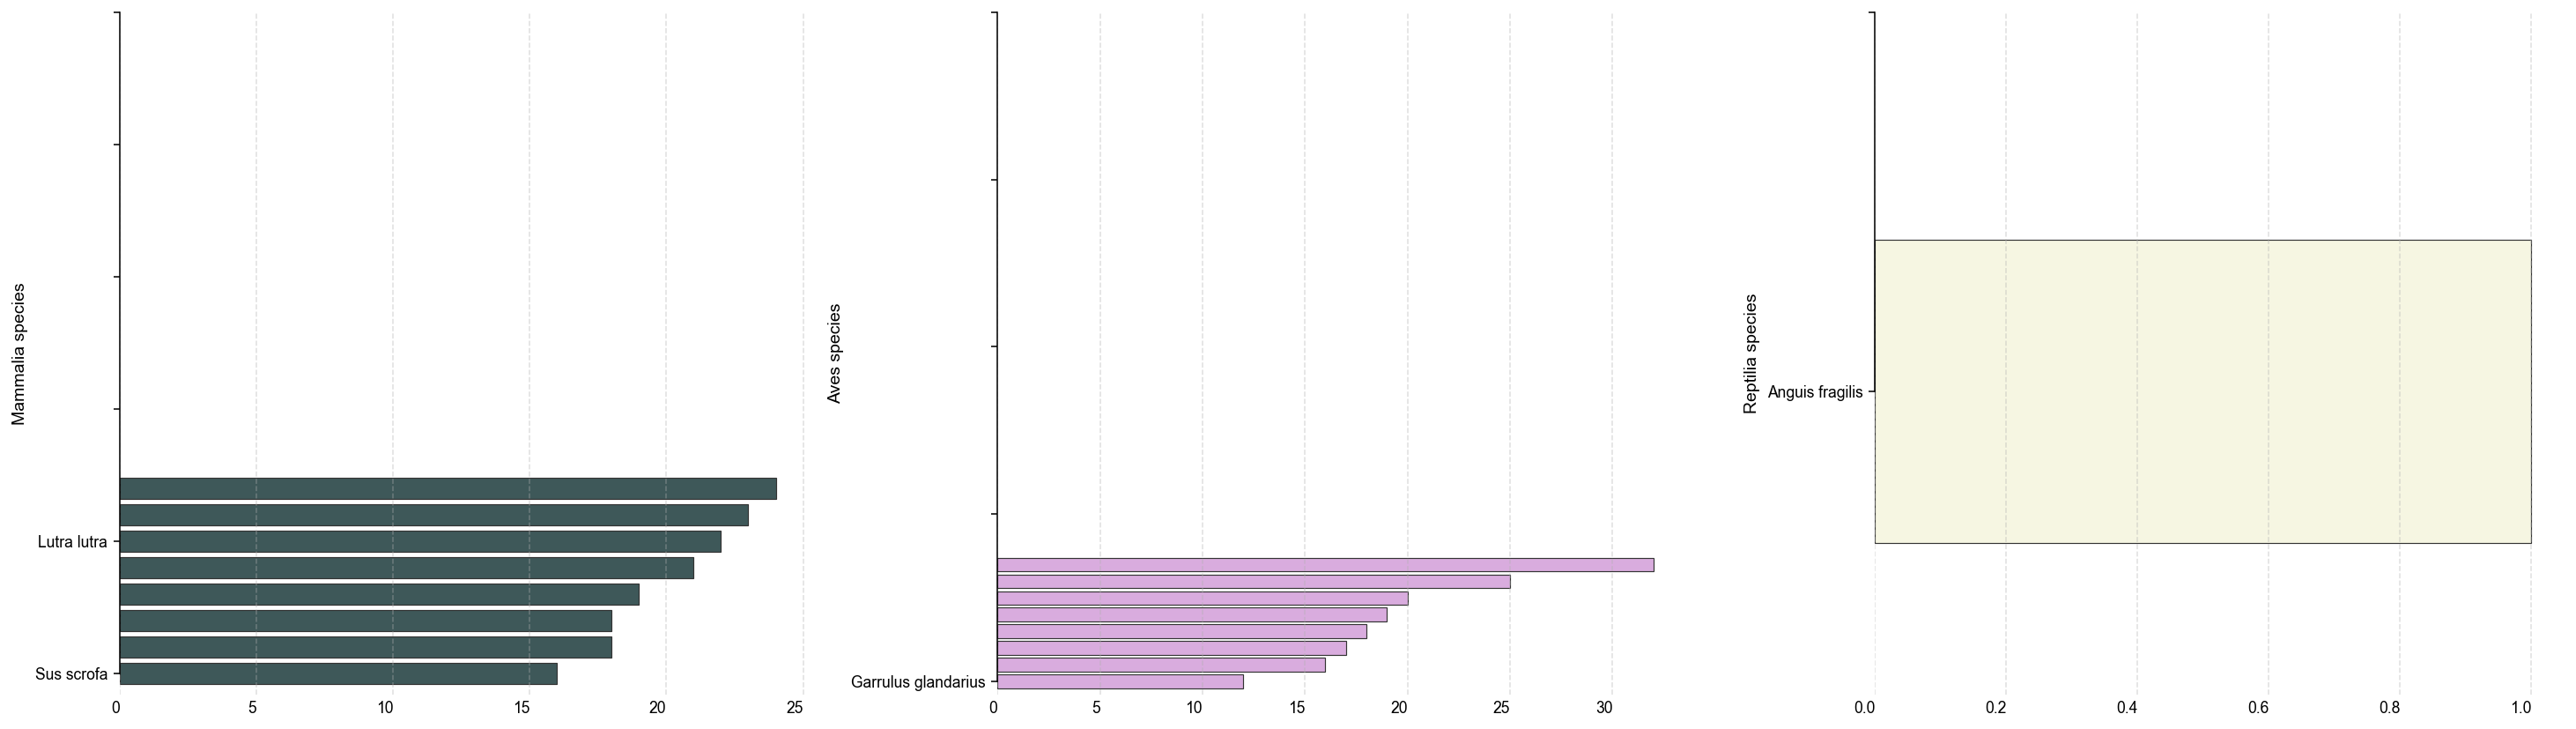

In [ ]:
fig = plot_top_species(camtrap, top_n=10)
fig


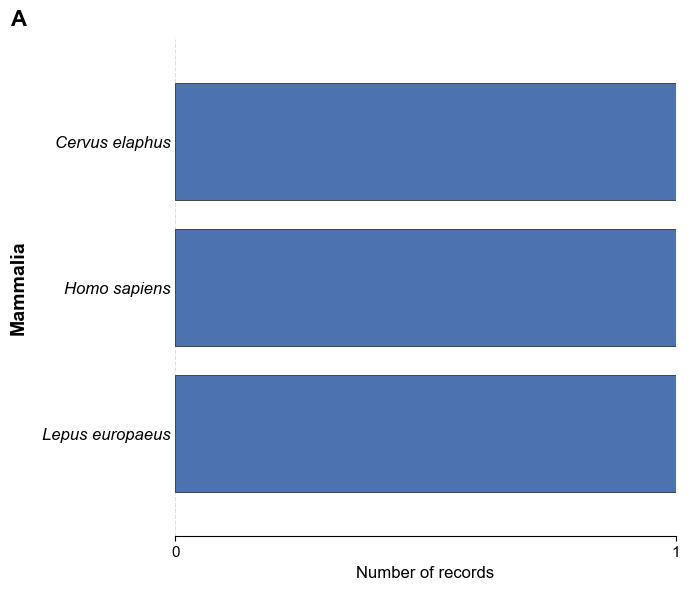

In [21]:
# Restrict to selected classes / colors
fig = plot_top_species(
    camtrap,
    classes={"Mammalia": "#4C72B0", "Aves": "#55A868"},
    top_n=8,
)


### `plot_top_species_by_sensor`

Convenience wrapper that returns mammal/bird top-species figures for camera and bioacoustic data.


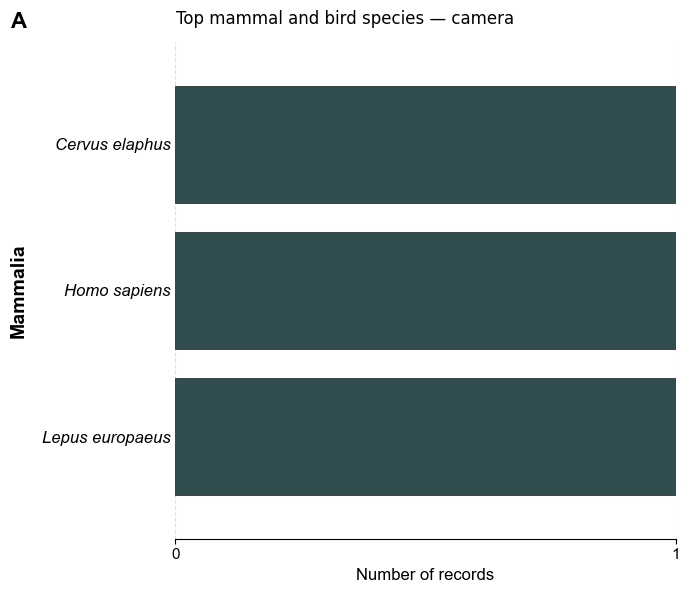

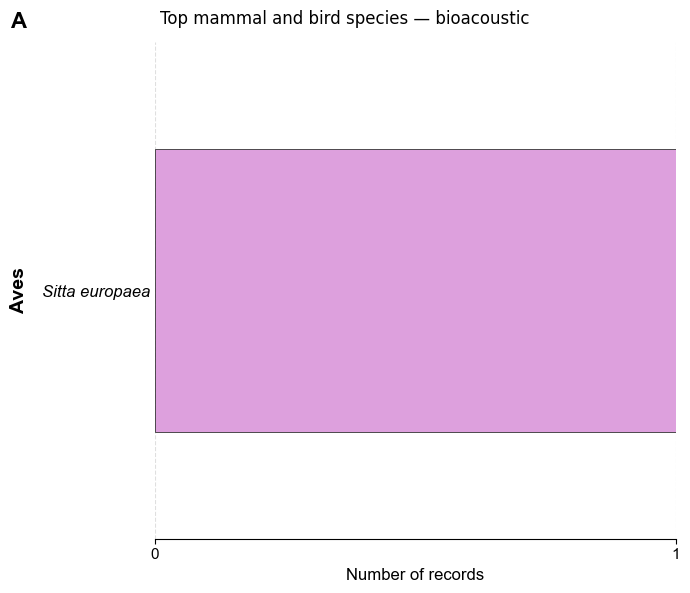

In [22]:
top_figs = plot_top_species_by_sensor(camtrap, audio, top_n=10)

for sensor, fig in top_figs.items():
    fig.suptitle(f"Top mammal and bird species — {sensor}")
    display(fig)
    plt.close(fig)


## 3. Species accumulation

Incidence-based mammal vs bird accumulation curves by sensor effort (camera-trap days / bioacoustic days).


### `plot_species_accumulation_mammal_bird_by_sensor`


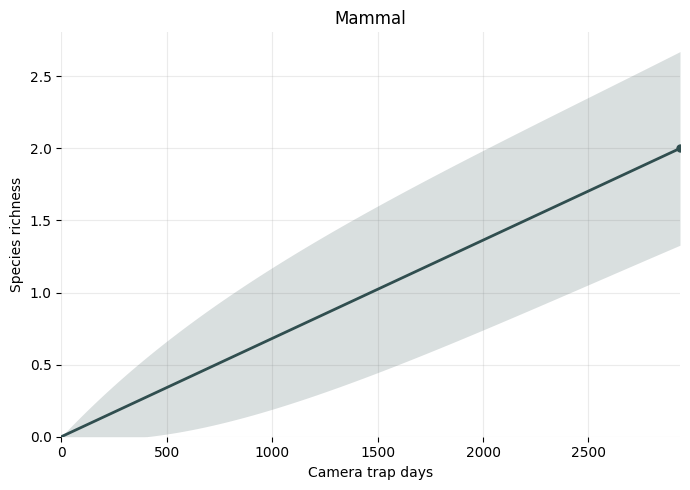

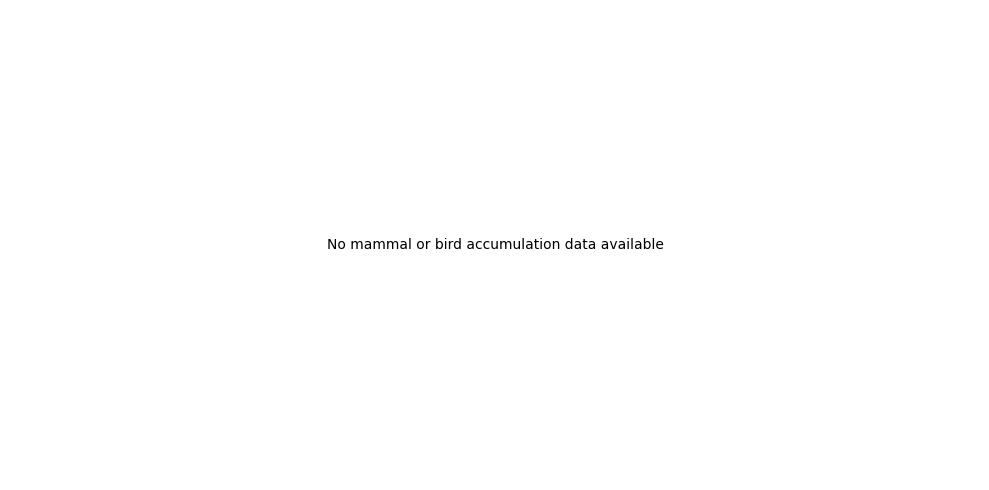

In [24]:
accumulation_figs = plot_species_accumulation_mammal_bird_by_sensor(
    camtrap,
    audio,
    stations,
)

for sensor, fig in accumulation_figs.items():
    display(fig)
    plt.close(fig)


## 4. eDNA and IUCN plots

Stacked identification-level charts for eDNA taxa, plus IUCN red-list status bars.


### `plot_edna_records`

Stacked bars of unique taxa by taxonomic class, colored by lowest identification rank (Order / Family / Genus / Species).


""


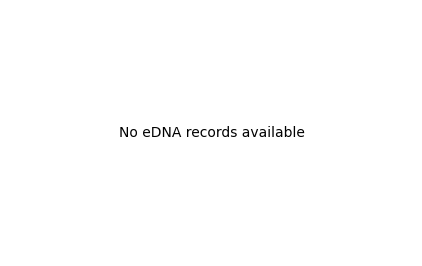

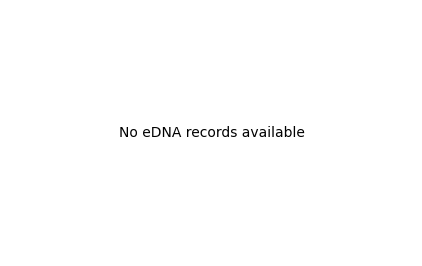

In [25]:
fig, edna_summary = plot_edna_records(edna, return_summary=True)
display(edna_summary)
fig


### `plot_edna_unique_taxa_stacked`

Legacy alias for `plot_edna_records` — same figure, kept for older report call sites.


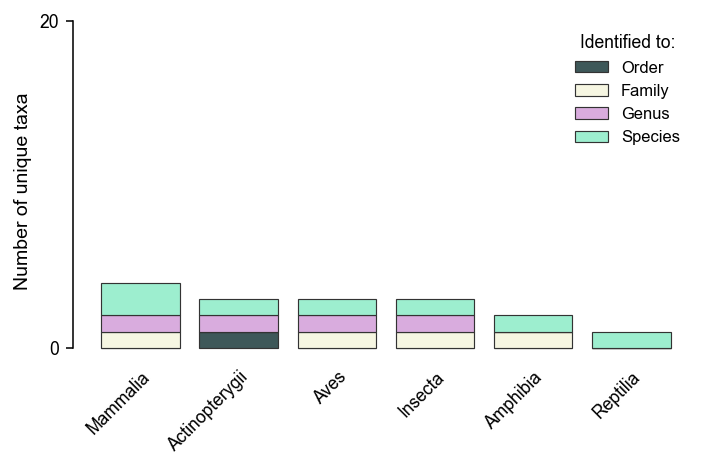

In [ ]:
fig = plot_edna_unique_taxa_stacked(edna)
fig


### `iucn_bar_plot`

Stacked bar chart of unique species by taxonomic class and IUCN status. Pass the IUCN column name used in your observation frame — typically `iucn_redlist_status`.


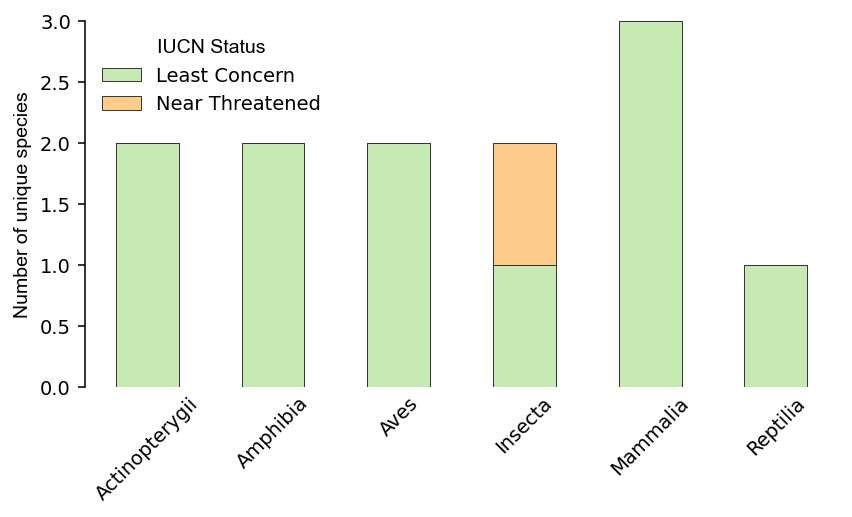

In [ ]:
# IUCN status from eDNA observations
fig = iucn_bar_plot(
    edna,
    class_col="class",
    species_col="species",
    iucn_col="iucn_redlist_status",
)
fig


iucn,class,Least Concern
0,Mammalia,3


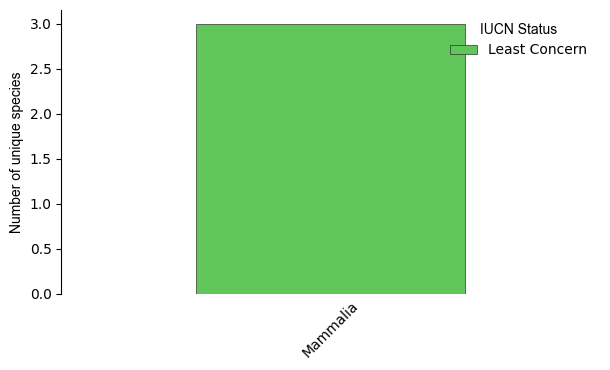

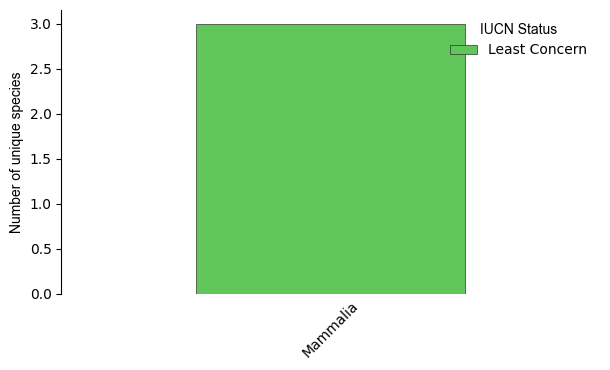

In [ ]:
# Same plotter works on camera-trap rows with IUCN enrichment
fig, iucn_summary = iucn_bar_plot(
    camtrap,
    class_col="class",
    species_col="species",
    iucn_col="iucn_redlist_status",
    return_summary=True,
)
display(iucn_summary)
